## Tutorial 7a: Fueture Construction

### transformers

These tasks arer done using transformers
sklearn's"transformer" is used for this, the main methods being: 
- transformers.fit()
- transformers.transform()
- transformers.fit_transformer()

Note that the ananlysis and fiting (traning) is based only on the train dataset. After that, the learned transformations are applied to the test data.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Load the data

In [7]:
df = sns.load_dataset("iris")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [8]:
# Saperate the target variable
X = df[df.columns[1:-1]] # read "-1" as "the last one"
y = df[df.columns[-1]]

In [9]:
# Show the nuber of instances per class
y.value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [10]:
# split the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train,  y_test = train_test_split(X,y, test_size= 0.3, random_state= 42, stratify=y)

In [11]:
# Check bofore standardization
X_train.head()

,sepal_width,petal_length,petal_width
98,2.5,3.0,1.1
68,2.2,4.5,1.5
19,3.8,1.5,0.3
143,3.2,5.9,2.3
99,2.8,4.1,1.3


### PCA

#### Standardize the Data

PCA is a affected by scale: you should give each of the features in your data a similar scale (mean = 0 and variance = 1) before applying PCA. We will use Standardize our dataset's features

In [15]:
# Now lets apply 1-1" StandardScaler" transformer
#1) import the module
from sklearn.preprocessing import StandardScaler

#2) define the model
scaler = StandardScaler()

#3) fit the model
scaler.fit(X_train)

#4)transform the data
X_train_ss = scaler.transform(X_train)

# note 3 and 4 could be combined like this:
# X_train_ss = SS.fit_transform(X_train)

### Run PCA

In [16]:
# now lets perform PCA
# Step are similar to the scale transformer 
#1) import the module
from sklearn.decomposition import PCA
#2) define the model
pca = PCA(n_components=2) # n_components means the pca transformation constructs this many features
# 3) fit the model
pca.fit(X_train_ss)
# 4) transform the data 
pca_train = pca.transform(X_train_ss)
# 3 and 4 could be combined
# pca_train = pca.fit_transform(X_train_ss)
# print the output, which is a matrix of only two features
pca_train[:10,:]
# ALT: plt.scatter(pca_train[:,0],pca_train[:,1])

array([[ 0.09953905, -1.27195338],
       [ 1.24517682, -1.511778  ],
       [-2.23995982,  0.82850939],
       [ 1.56980436,  1.02026044],
       [ 0.41457825, -0.43457392],
       [ 1.48337778,  0.51976305],
       [-1.80491446, -0.66531921],
       [-2.2865126 ,  0.80241998],
       [-1.58636569, -1.04325442],
       [ 1.57485976,  0.53649337]])

### Visualising the results

possible if it's 2d

<Axes: xlabel='pc1', ylabel='pc2'>

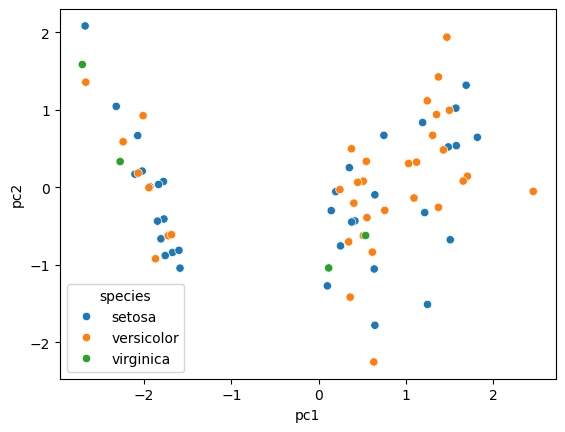

In [17]:
# format and visualise the transformed training data
df_pca_train = pd.DataFrame(data = pca_train, columns=["pc1", "pc2"])
df_pca_train["species"] = y_train
sns.scatterplot(x = "pc1", y ="pc2", hue = df_pca_train["species"], data = df_pca_train)

### Transform the test data

note: Here we only apply the learned transformers to transform the test data, No fit is used

In [ ]:
#1- First apply the scaler that has been built based on the training data to scale the test data
X_test_ss = scaler.transform(X_test)
#2- Second apply the pca transformation that has been built based on the training data to transfer the scaled test data
pca_test = pca.transform(X_test_ss)

### Classification

In [ ]:
#Performing classification based on the orignal data
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(random_state= 0)
#classifier = SVC()
classifier.fit(X_train, y_train)
score = accuracy_score(classifier.predict(X_test), y_test)
